# Singular Spectrum Analysis (SSA)

https://www.kaggle.com/code/jdarcy/introducing-ssa-for-time-series-decomposition#Decomposing-Time-Series-Data-With-Singular-Spectrum-Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

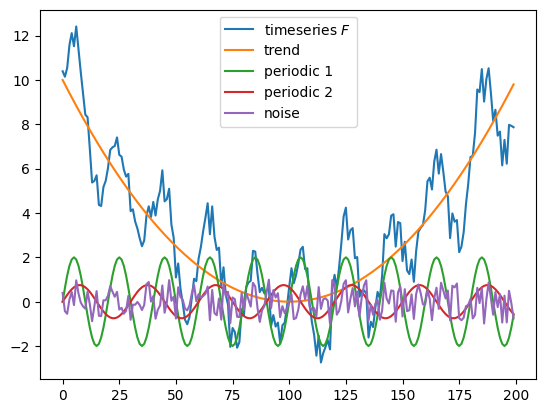

In [5]:
N = 200
t = np.arange(0,N)

trend = 0.001 * (t - 100)**2
p1, p2 = 20, 30
periodic1 = 2 * np.sin(2*np.pi*t/p1)
periodic2 = 0.75 * np.sin(2*np.pi*t/p2)

np.random.seed(123)
noise = 2 * (np.random.rand(N) - 0.5)

F = trend + periodic1 + periodic2 + noise

plt.plot(F, label='timeseries $F$')
plt.plot(trend, label='trend')
plt.plot(periodic1, label='periodic 1')
plt.plot(periodic2, label='periodic 2')
plt.plot(noise, label='noise')

plt.legend()

In [7]:
def delay_embed(feats, L=10):
    """
    Create lag embeddings for multivariate time series.
    
    Parameters:
    -----------
    feats : shape (T, D)
    L : number of time lags to include
    
    Returns:
    --------
    embedded : shape (T - n_lags + 1, D * n_lags)
    """
    T, D = feats.shape
    return np.hstack([feats[i:T-L+i, :] for i in range(L)])

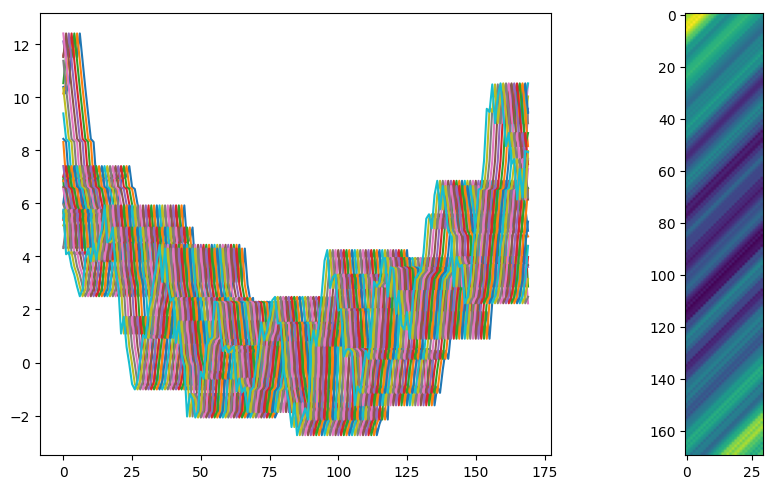

In [60]:
k_lags = 30

F_lag = delay_embed(F[..., None], L=k_lags)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.plot(F_lag, )
ax2.imshow(F_lag)
plt.tight_layout()

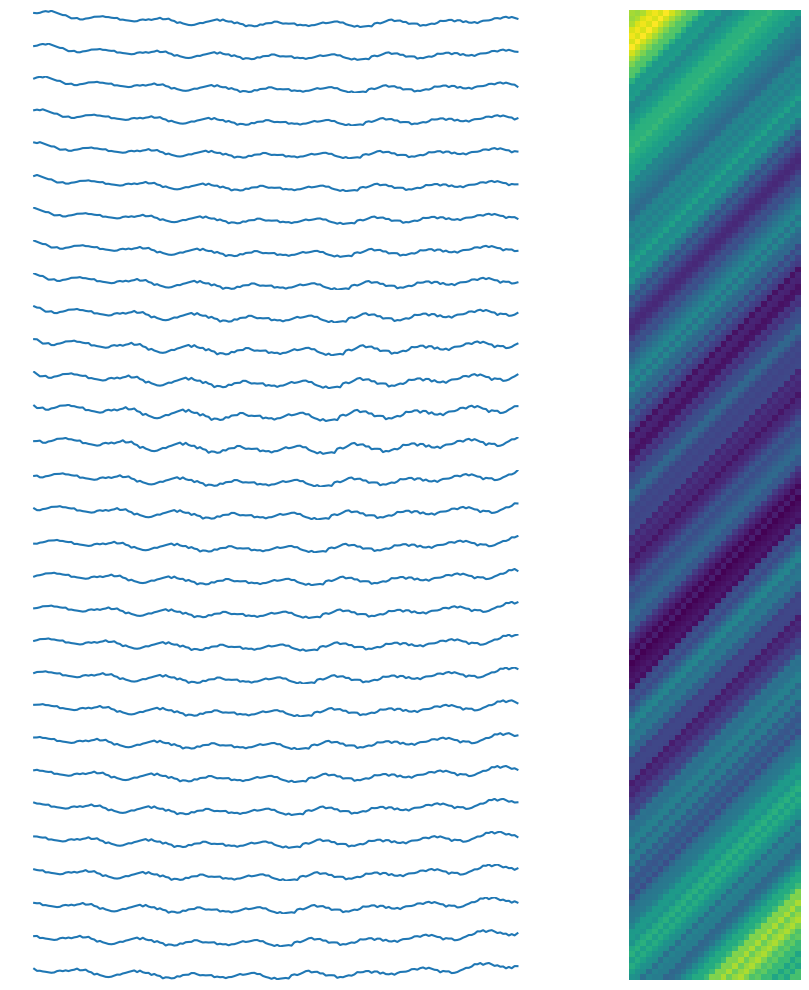

In [ ]:
fig = plt.figure(figsize=(10, 10))

for k in range(k_lags):
    ax = fig.add_subplot(k_lags, 2, 2*k+1) # odd indices
    ax.plot(F_lag[:, k])
    ax.axis('off')

ax = fig.add_subplot(1, 2, 2)
ax.imshow(F_lag)
ax.axis('off')

plt.tight_layout()

In [62]:
def SSA(traj_X):
    # apply SVD on trajectory matrix
    U, s, Vt = np.linalg.svd(traj_X, full_matrices=False)

    # tolerance for considering a singular value to be zero
    tol = s.max() * np.maximum(*traj_X.shape) * np.finfo(traj_X.dtype).eps
    d = (s > tol).sum()
    X_elem = np.array([s[i] * np.outer(U[:,i], Vt[i, :]) for i in range(0,d)] )

    return X_elem, U, s, Vt

F_elem, U, s, Vt = SSA(F_lag)

F_elem.shape, U.shape, s.shape, Vt.shape

((30, 170, 30), (170, 30), (30,), (30, 30))

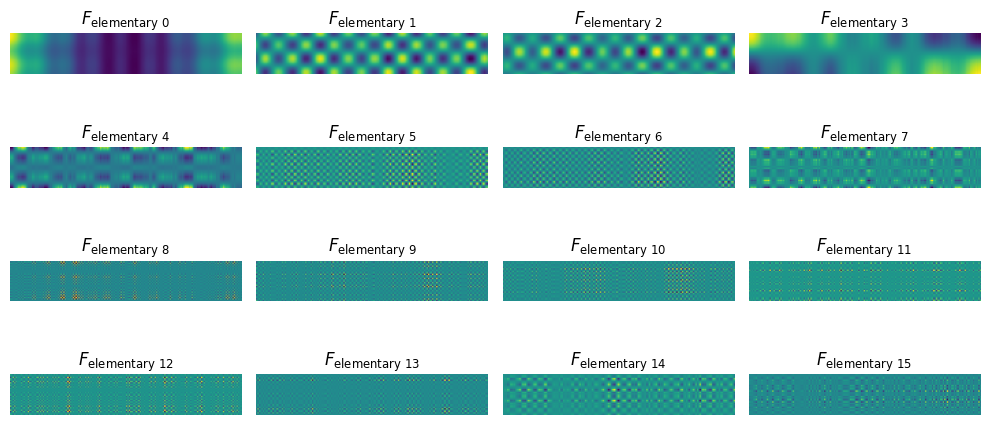

In [63]:
fig = plt.figure(figsize=(10, 5))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(F_elem[i].T)
    plt.axis('off')
    plt.title(fr'$F_{{\text{{elementary }} {i}}}$')

plt.tight_layout()

In [68]:
Vt[:3].T.shape, F_lag.shape

((30, 3), (170, 30))

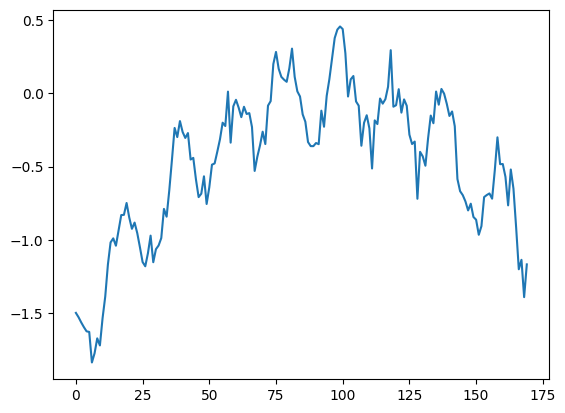

In [100]:
pca_F = (F_lag @ Vt[:].T)

plt.plot(pca_F.mean(axis=1))

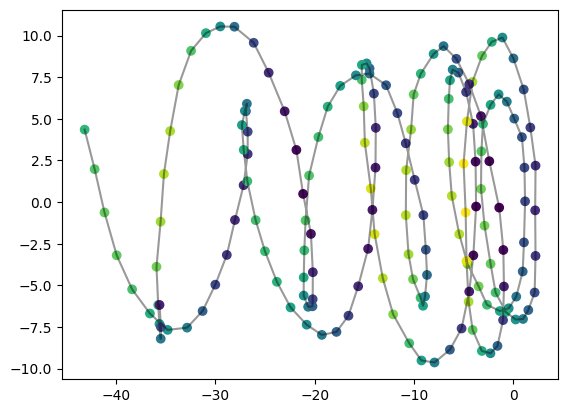

In [99]:
plt.plot(pca_F[:, 0], pca_F[:, 1], color='black', alpha=.4)
plt.scatter(pca_F[:, 0], pca_F[:, 1], c=pca_F[:, 2])